<a href="https://colab.research.google.com/github/marvellousadeoluwa/Deep-Learning/blob/master/lesson_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install fastai -qqq
!pip install fastai2 -qqq

In [ ]:
#from utils import *
from fastai2.vision.widgets import *

## Deep Learning using fast.ai
* Python
* Pytorch
* Fast.ai
* GPU( always run your codes on GPUs, eg COLAB )
### All materials used can be gotten from www.fast.ai
* Updown approach

### the fast.ai library can be used to implement a single pipeline which can be used for many task(image classification, text recognition, etc

- vision, task

# Task 1 - Image Classification
- Image Classification
- labels: cat or dog
- all label/data starting with capital letter are considered as cat
- fast.ai library provides default dataset from untar_data module/function
- *untar_data(URLs.PETS)/'images'* imported from *fastai2.vision.all*
- a dataset of pictures of dogs and cats
### Note: Later version can contain *fastai.vision.all* i.e without the 2 and fastai has taken care of importing everything (* )

* You can use the normal procedure in production eg. from fastai import ...

In [ ]:
from fastai2.vision.all import *
path = untar_data(URLs.PETS)/'images' 

def is_cat(x):
    return x[0].isupper()

dls = ImageDataLoaders.from_name_func(path, get_image_files(path),
                                     valid_pct= 0.2, seed= 42,
                                     label_func= is_cat,
                                     item_tfms = Resize(224))

learn = cnn_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


epoch,train_loss,valid_loss,error_rate,time
0,0.169666,0.019699,0.005413,00:43


epoch,train_loss,valid_loss,error_rate,time
0,0.071336,0.036931,0.009472,00:44


In [ ]:
# creating a widget to pick and upload files/pictures
uploader = widgets.FileUpload()
uploader

FileUpload(value={}, description='Upload')

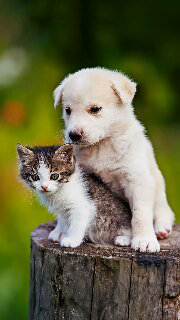

In [ ]:
# Import new image to test model with
img = PILImage.create(uploader.data[0])
img

In [ ]:
is_cat,_,probs = learn.predict(img)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")

Is this a cat?: False.
Probability it's a cat: 0.127195


In [ ]:
uploader2 = widgets.FileUpload()
uploader2

FileUpload(value={}, description='Upload')

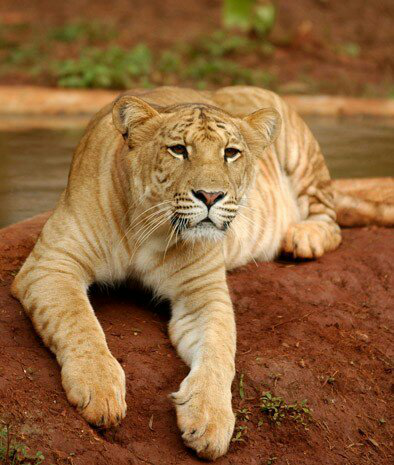

In [ ]:
img2 = PILImage.create(uploader2.data[0])
img2

In [ ]:
is_cat,_,probs = learn.predict(img2)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")

Is this a cat?: True.
Probability it's a cat: 0.999191


### The dataset contains only pictures of cats and dogs not anime, drawings, stickers or even sketches
* So the model is only trained on such

* path = dataset gotten from untar_data()
* is_cat() = a user_defined function that returns all capitalized label as cat
* dls
    * path = data
    
         - /'images' converts data to python obj, you can also use /'annotations' for annotations
         - path.ls() ; tells you what is contained in the path
    * get_image_files(path)
    
    * valid_pct = validation set
    * size = shape of all images
        - since GPU applies same action on all data
        - this converts all imaages to the same size
* learn = model, 

* img = new data/picture to classify/test data on

In [ ]:
doc(ImageDataLoaders)

ImageDataLoaders(*loaders, path='.', device=None)
Basic wrapper around several `DataLoader`s with factory methods for computer vision problems

To get a prettier result with hyperlinks to source code and documentation, install nbdev: pip install nbdev


In [ ]:
path.ls()

(#7393) [Path('/root/.fastai/data/oxford-iiit-pet/images/Bengal_151.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/saint_bernard_171.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/yorkshire_terrier_125.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/Birman_111.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/leonberger_45.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/Sphynx_185.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/Ragdoll_159.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/wheaten_terrier_26.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/Bombay_14.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/Abyssinian_137.jpg')...]

In [ ]:
fnames = get_image_files(path)

pat = r'/([^/]+)_\d+.jpg$' #...regex to get file extension, pattern

fnames[:5] # to see the images

(#5) [Path('/root/.fastai/data/oxford-iiit-pet/images/Bengal_151.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/saint_bernard_171.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/yorkshire_terrier_125.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/Birman_111.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/leonberger_45.jpg')]



```
# TASK 2: fOR SEGMENTATIONS AS WELL


```



In [ ]:
path = untar_data(URLs.CAMVID_TINY)/'images' 


dls = SegmentationDataLoaders.from_label_func(
    path, bs=8, fnames= get_image_files(path/'images'),
    label_func= lambda o: path/'labels'/f'(o.stem)_P(o.suffix)',
    codes = np.loadtxt(path/'codes.txt', dtype=str)
    )

learn = unet_learner(dls, resnet3)
learn.fine_tune(8)

OSError: ignored

In [ ]:
# from_name_re
# another is ImageDataBunch, an object that contains all images you need to train a model
# so all data will be in databunch obj datatype

data = ImageDataBunch.from_name_re(path, fnames, pat,
                                   ds_tfsm=get_transforms(),
                                  size=224)

# normalize helps to take of the pixel values/ quality e.g brightness
data.normalize(imagenet_stats)

NameError: ignored

In [ ]:
data.show_batch(rows=3, figsize=(7,6))
#show contents eg... 3 by 3

NameError: ignored

In [ ]:
data.classes, data.c #for classification prob

# Training resnet34 or 50
* we train a model using a learner in fastai
* learner
* ConvLearner = Convolusional Neural Network
* aka Architecture

In [ ]:
learn = ConvLearner(data, models.resnet34, metric=error_rate)
# at first, by defaults, it downloads about 1 mil of pretrained weight
# it  

In [ ]:
learn.fit_one_cycle(4)